In [ ]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

train_images = torch.stack([trainset[i][0] for i in range(len(trainset))])
test_images = torch.stack([testset[i][0] for i in range(len(testset))])

train_mean = train_images.mean().item()
train_std = train_images.std().item()
print(f"train_images - Media: {train_mean:.4f}, Std: {train_std:.4f}")

test_mean = test_images.mean().item()
test_std = test_images.std().item()
print(f"test_images - Mean: {test_mean:.4f}, Std: {test_std:.4f}")

train_images - Media: 0.1307, Std: 0.3081
test_images - Media: 0.1325, Std: 0.3105


In [18]:
# Normalization 
from torchvision import datasets, transforms

data_dir = "./data"

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((test_mean,), (test_std,))
    ])

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((train_mean,), (train_std,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

In [19]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()


test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

train_images = images_extractor(trainset)
train_labels = labels_extractor(trainset) # will be the groundtruth by the end of the task

In [31]:
test_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(test_images_cnn.shape)

(10000, 28, 28, 1)


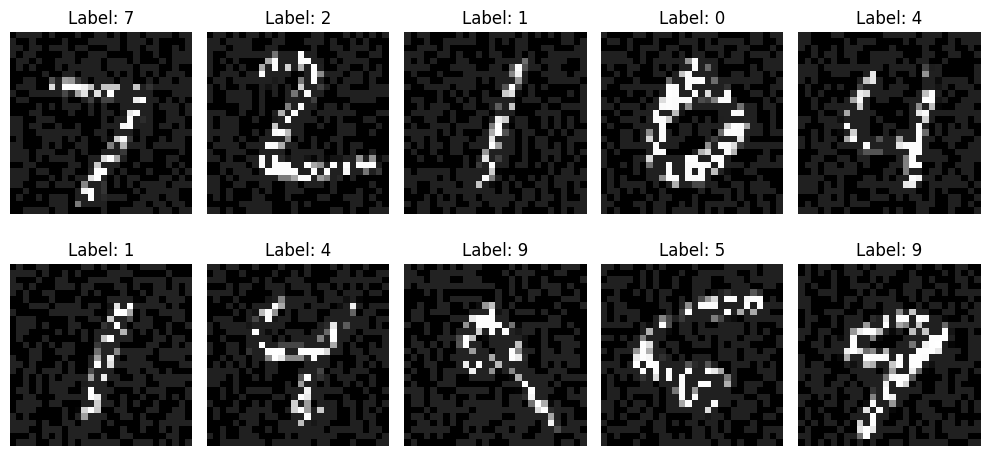

In [32]:
import matplotlib.pyplot as plt
import numpy as np

drop_prob = 0.5
drop_mask = np.random.rand(*test_images_cnn.shape) > drop_prob
test_images_dropped = test_images_cnn * drop_mask


plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = test_images_dropped[i, :, :, 0]
    img_display = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Label: {test_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images_dropped.png', dpi=150)
plt.show()


In [33]:
from sklearn.model_selection import train_test_split

# Primero dividimos en entrenamiento (70%) y prueba (30%)
train_images, test_images, train_labels, test_labels = train_test_split(
    test_images_cnn, 
    test_labels, 
    test_size=0.3, 
    random_state=42
)

# Luego dividimos el conjunto de prueba en validación (15%) y prueba final (15%)
val_images, test_images, val_labels, test_labels = train_test_split(
    test_images, 
    test_labels, 
    test_size=0.5, 
    random_state=42
)


In [34]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3),
        activation='relu', 
        input_shape=(28, 28, 1)
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


/workspace/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
epochs = 10  
batch_size = 200
learn_rate = 0.001

fit_model = model.fit(
    train_images, #subset of test_images
    train_labels,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_data=(val_images,val_labels)
    )

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=0
    )

print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4094 - loss: 1.7272 - val_accuracy: 0.8380 - val_loss: 0.7613
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7290 - loss: 0.8255 - val_accuracy: 0.9140 - val_loss: 0.3930
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8290 - loss: 0.5249 - val_accuracy: 0.9373 - val_loss: 0.2559
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8779 - loss: 0.3841 - val_accuracy: 0.9547 - val_loss: 0.1852
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8996 - loss: 0.3163 - val_accuracy: 0.9613 - val_loss: 0.1552
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9169 - loss: 0.2782 - val_accuracy: 0.9607 - val_loss: 0.1379
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9263 - loss: 0.2351 - val_accuracy: 0.9613 - val_loss: 0.1187
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9340 - loss: 0.2140 - val_accuracy: 0.9653 - v

In [36]:
print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Test accuracy: {test_acc:.4f}")  # Añadimos la precisión en el conjunto de prueba
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")
print(f"Test loss: {test_loss:.4f}") 

Final training accuracy: 0.9449
Final validation accuracy: 0.9680
Test accuracy: 0.9700
Final training loss: 0.1776
Final validation loss: 0.0970
Test loss: 0.1015


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


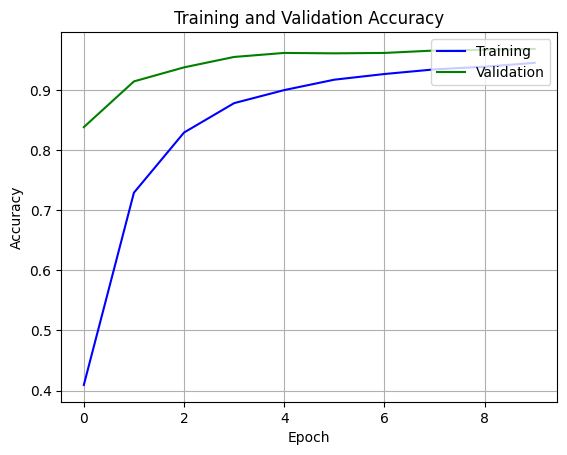

In [37]:
import matplotlib.pyplot as plt

_ = model.predict(test_images_cnn[:1])

plt.plot(fit_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

In [38]:
# embedding


import tensorflow as tf

layer_names = [layer.name for layer in fit_model.layers]
print(layer_names)

dense_layers = [layer.name for layer in fit_model.layers 
                if isinstance(layer, tf.keras.layers.Dense)]
print("Available Dense layzers:", dense_layers)
selected_layer = dense_layers[-1]
print(selected_layer)


AttributeError: 'History' object has no attribute 'layers'